Task 1: The Tiny Fingerprint - Linear Scale

Original size: 80 x 80 pixels - way too small!
Goal: scale up 300% on both axes and center it on screen.

2x2 Scaling Matrix:
[[3. 0.]
 [0. 3.]]

Each x-coordinate will be multiplied by 3.0
Each y-coordinate will be multiplied by 3.0

Scaled image size: 240 x 240
Screen size:        800 x 600
Centering offset:   tx = 280.0, ty = 180.0

2x3 Affine Matrix (scale + centering translation):
[[  3.   0. 280.]
 [  0.   3. 180.]]


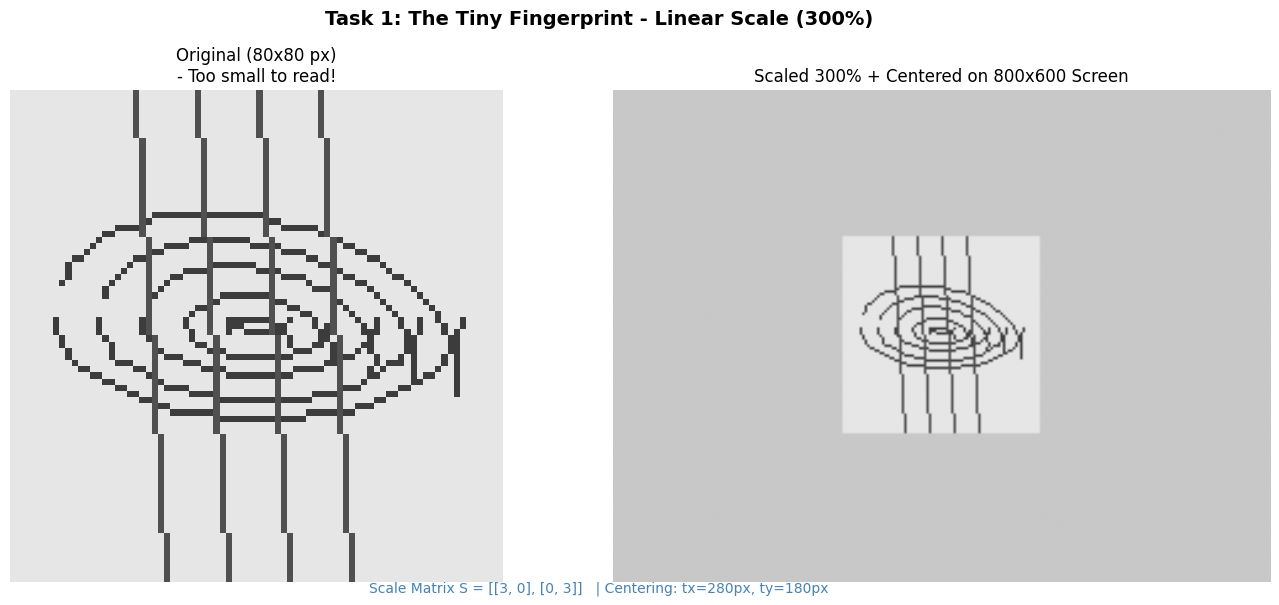


[Done] Output saved to output/task1_scale.png


In [1]:
"""
Task 1: The Tiny Fingerprint (Linear - Scale)

Scenario:
    You're a detective analyzing a digital fingerprint from a crime scene,
    but the image is way too small to read. We need to enlarge it.

Task:
    - Manually build a 2x2 scaling matrix
    - Enlarge the fingerprint by 300% on both x and y axes
    - Calculate the translation needed to keep it perfectly centered on screen
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)


def make_fingerprint_image(size=80):
    """
    Creates a small synthetic fingerprint-like image using concentric arcs.
    In a real scenario you'd load an actual fingerprint image here.
    """
    img = np.ones((size, size), dtype=np.uint8) * 230  # off-white background

    cx, cy = size // 2, size // 2

    # Draw concentric elliptical arcs to simulate fingerprint ridges
    for r in range(5, size // 2 - 2, 7):
        cv2.ellipse(img, (cx, cy), (r, int(r * 0.6)), 15, 180, 360, 60, 1)
        cv2.ellipse(img, (cx, cy - 3), (r, int(r * 0.5)), 0, 0, 180, 60, 1)

    # Add a few crossing lines to make it look more like a real print
    for offset in range(-size // 4, size // 4, 10):
        cv2.line(img, (cx + offset, 0), (cx + offset + 5, size), 80, 1)

    return img


# --- Load (or create) the fingerprint image ---
fingerprint = make_fingerprint_image(size=80)
h, w = fingerprint.shape[:2]

print("=" * 50)
print("Task 1: The Tiny Fingerprint - Linear Scale")
print("=" * 50)
print(f"\nOriginal size: {w} x {h} pixels - way too small!")
print("Goal: scale up 300% on both axes and center it on screen.\n")


# --- Step 1: Build the 2x2 Scaling Matrix ---
#
# A 2D linear scale transformation is:
#
#   [ x' ]   [ sx   0 ] [ x ]
#   [ y' ] = [  0  sy ] [ y ]
#
# sx = 3.0 means 300% on x-axis (3x original size)
# sy = 3.0 means 300% on y-axis (3x original size)

sx = 3.0   # 300% horizontal scale factor
sy = 3.0   # 300% vertical scale factor

S = np.array([
    [sx,  0.0],
    [0.0,  sy]
], dtype=np.float64)

print("2x2 Scaling Matrix:")
print(S)
print(f"\nEach x-coordinate will be multiplied by {sx}")
print(f"Each y-coordinate will be multiplied by {sy}")


# --- Step 2: Calculate centering offset ---
#
# After scaling, the image dimensions become:
#   new_w = w * sx = 80 * 3 = 240
#   new_h = h * sy = 80 * 3 = 240
#
# To center this on a fixed 800x600 screen:
#   tx = (screen_w - new_w) / 2   <-- shift right to center horizontally
#   ty = (screen_h - new_h) / 2   <-- shift down to center vertically

screen_w, screen_h = 800, 600
new_w = int(w * sx)
new_h = int(h * sy)

tx = (screen_w - new_w) / 2.0
ty = (screen_h - new_h) / 2.0

print(f"\nScaled image size: {new_w} x {new_h}")
print(f"Screen size:        {screen_w} x {screen_h}")
print(f"Centering offset:   tx = {tx:.1f}, ty = {ty:.1f}")


# --- Step 3: Build the 2x3 Affine Matrix ---
#
# cv2.warpAffine() takes a 2x3 matrix that does scale AND translate in one step:
#
#   [ sx    0   tx ]
#   [  0   sy   ty ]
#
# The third column handles the centering translation.

M = np.float32([
    [sx,   0.0,  tx],
    [0.0,  sy,   ty]
])

print("\n2x3 Affine Matrix (scale + centering translation):")
print(M)


# --- Step 4: Apply the transformation ---
result = cv2.warpAffine(
    fingerprint, M,
    (screen_w, screen_h),
    flags=cv2.INTER_LINEAR,    # bilinear interpolation gives smoother edges
    borderValue=200            # fill empty screen space with light gray
)


# --- Visualize results ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Task 1: The Tiny Fingerprint - Linear Scale (300%)',
             fontsize=14, fontweight='bold')

axes[0].imshow(fingerprint, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Original ({w}x{h} px)\n- Too small to read!')
axes[0].axis('off')

axes[1].imshow(result, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Scaled 300% + Centered on {screen_w}x{screen_h} Screen')
axes[1].axis('off')

matrix_text = (f"Scale Matrix S = [[{sx:.0f}, 0], [0, {sy:.0f}]]   "
               f"| Centering: tx={tx:.0f}px, ty={ty:.0f}px")
fig.text(0.5, 0.01, matrix_text, ha='center', fontsize=10, color='steelblue')

plt.tight_layout()
plt.savefig('output/task1_scale.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n[Done] Output saved to output/task1_scale.png")